In [77]:
import pandas as pd

In [78]:
df = pd.read_csv('C:/CODING STUFF/Customer_churn_prediction_platform/Data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [79]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [80]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [81]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [82]:
df.shape

(7043, 21)

In [83]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [84]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [85]:
df['TotalCharges'].dtype

dtype('float64')

In [86]:
import seaborn as sns

<Axes: xlabel='TotalCharges', ylabel='Churn'>

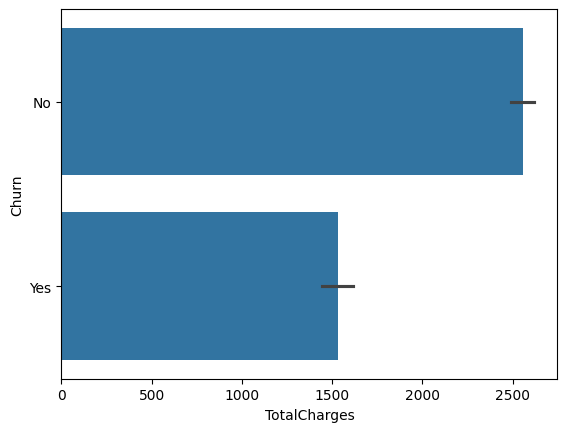

In [87]:
sns.barplot(x=df['TotalCharges'],y=df['Churn'])

<Axes: xlabel='Churn', ylabel='MonthlyCharges'>

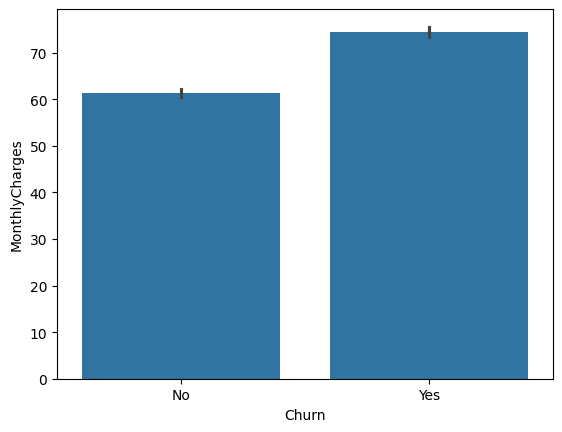

In [88]:
sns.barplot(x=df['Churn'],y=df['MonthlyCharges'])

In [89]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['TotalCharges'].median()
)

In [90]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [91]:
df.drop('customerID',axis=1,inplace=True)

In [92]:
df = pd.get_dummies(df,drop_first=True)


In [93]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,True,False,True,False,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,True,False,False,True,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,True,False,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,True,False,True,False,True


In [94]:
X = df.drop('Churn_Yes',axis=1)
y = df['Churn_Yes']
print(X.columns.tolist())

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [95]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [96]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [97]:
from sklearn.linear_model import LogisticRegression
LogisticModel = LogisticRegression(max_iter=1000)

In [98]:
LogisticModel.fit(X_train,y_train)

c:\Users\Abhinav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [99]:
y_pred=LogisticModel.predict(X_test)

In [100]:
import matplotlib.pyplot as plt

StandardScaler was applied after train-test splitting to normalize numerical feature ranges. Features such as tenure, MonthlyCharges, and TotalCharges had significantly different scales, which could negatively affect Logistic Regression optimization and convergence. Scaling transformed the data to a standardized distribution with mean 0 and standard deviation 1, improving model stability, convergence speed, and overall training performance.


In [101]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test,y_pred)

In [102]:
acc

0.8211497515968772

In [103]:
from sklearn.metrics import confusion_matrix

In [104]:
cm = confusion_matrix(y_test,y_pred)

In [105]:
cm

array([[933, 103],
       [149, 224]])

In [106]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.86      0.90      0.88      1036
        True       0.69      0.60      0.64       373

    accuracy                           0.82      1409
   macro avg       0.77      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



The Logistic Regression model achieved high recall for churn prediction, successfully identifying most churned customers. However, precision was very low, indicating that the model incorrectly classified a large number of non-churn customers as churners. This resulted in poor overall accuracy and a high number of false positives. The results suggest that while the model is effective at detecting churners, further optimization and class balancing are required to improve prediction reliability.


Today, I learned the initial stages of the machine learning pipeline using a customer churn dataset. I understood how to split the dataset into training and testing sets using train_test_split and why this step is important for evaluating model generalization on unseen data. I also trained my first Logistic Regression classification model and learned how model prediction works.

Additionally, I learned the importance of feature scaling using StandardScaler. Since numerical features had significantly different ranges, scaling was necessary to improve optimization stability and help the Logistic Regression model converge more effectively during training.

Finally, I evaluated the model using confusion matrix, accuracy, precision, recall, and F1-score, which helped me understand why model evaluation is more important than relying only on accuracy.


In [107]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check',
       'Churn_Yes'],
      dtype='str')

In [108]:
df['Churn_Yes'].value_counts()

Churn_Yes
False    5174
True     1869
Name: count, dtype: int64

In [109]:
df['Churn_Yes'].value_counts(normalize=True) * 100

Churn_Yes
False    73.463013
True     26.536987
Name: proportion, dtype: float64

In [110]:
y_pred[:20]


array([ True, False, False,  True, False, False, False, False, False,
       False, False, False, False,  True, False,  True, False,  True,
       False, False])

In [111]:
y_test[:20]

185      True
2715    False
3825    False
1807     True
132     False
1263     True
3732    False
1672    False
811      True
2526     True
2892    False
4129    False
2622    False
3801     True
4357    False
6179     True
5275     True
4640     True
833     False
5194     True
Name: Churn_Yes, dtype: bool

In [112]:
pd.Series(y_pred).value_counts()

False    1082
True      327
Name: count, dtype: int64

In [113]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nPrediction Distribution:")
print(pd.Series(y_pred).value_counts())

print("\nActual Distribution:")
print(pd.Series(y_test).value_counts())

[[933 103]
 [149 224]]

Prediction Distribution:
False    1082
True      327
Name: count, dtype: int64

Actual Distribution:
Churn_Yes
False    1036
True      373
Name: count, dtype: int64


Random Forest is an ensemble learning algorithm that combines multiple Decision Trees to make predictions. Each tree is trained on a random subset of data and features, and the final prediction is determined through majority voting. This approach reduces overfitting, improves generalization, and enables the model to capture complex non-linear relationships that may not be detected by simpler algorithms such as Logistic Regression.

type.x_train

In [114]:
type(X_train)

pandas.DataFrame

In [115]:
X_train.shape

(5634, 30)

In [116]:
from sklearn.ensemble import RandomForestClassifier

In [117]:
RandomForest = RandomForestClassifier(random_state=42)

In [118]:
RandomForest.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [119]:
rf_prediction = RandomForest.predict(X_test)

In [120]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_prediction))

              precision    recall  f1-score   support

       False       0.82      0.91      0.86      1036
        True       0.64      0.46      0.54       373

    accuracy                           0.79      1409
   macro avg       0.73      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409



Random Forest was trained and evaluated using the same train-test split as Logistic Regression. Although Random Forest is a more complex ensemble model, it achieved lower recall and F1-score for churn prediction compared to Logistic Regression. This demonstrated that more complex algorithms do not always outperform simpler models, and model selection should be based on evaluation metrics rather than assumptions.

In [121]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': RandomForest.feature_importances_
})

feature_importance.sort_values(
    'Importance',
    ascending=False
).head(10)

,Feature,Importance
3,TotalCharges,0.189701
1,tenure,0.175710
2,MonthlyCharges,0.172418
10,InternetService_Fiber optic,0.036053
28,PaymentMethod_Electronic check,0.035302
25,Contract_Two year,0.030435
13,OnlineSecurity_Yes,0.029238
4,gender_Male,0.027423
26,PaperlessBilling_Yes,0.025295
5,Partner_Yes,0.024209


# DAY 3


ROC Curve evaluates model performance across all classification thresholds by comparing True Positive Rate and False Positive Rate. AUC measures the area under the ROC Curve and indicates the model's ability to distinguish between positive and negative classes. Higher AUC values indicate better classification performance, especially in imbalanced datasets where accuracy may be misleading.


In [122]:
Output_prediction = LogisticModel.predict(X_test)

In [123]:
Output_prediction

array([ True, False, False, ..., False, False,  True], shape=(1409,))

In [124]:
Output_prediction[:20]

array([ True, False, False,  True, False, False, False, False, False,
       False, False, False, False,  True, False,  True, False,  True,
       False, False])

In [125]:
pd.DataFrame(Output_prediction)

,0
0,True
1,False
2,False
3,True
4,False
...,...
1404,False
1405,False
1406,False
1407,False


Lets calculate the ROC/AUC

In [126]:
LogisticModel.classes_

array([False,  True])

In [127]:
y_prob = LogisticModel.predict_proba(X_test)[:,1] # select only the first column not the zeroth column cause the first col shows that the customer churned

In [128]:
y_prob

array([0.69509872, 0.05959056, 0.00434472, ..., 0.05122722, 0.01258665,
       0.50404702], shape=(1409,))

In [129]:
pd.DataFrame(y_prob)

,0
0,0.695099
1,0.059591
2,0.004345
3,0.613869
4,0.005788
...,...
1404,0.014522
1405,0.098060
1406,0.051227
1407,0.012587


In [130]:
from sklearn.metrics import roc_curve
fpr,tpr,threshold = roc_curve(y_test,y_prob)


In [131]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test,y_prob)
print(auc)

0.86230682041674


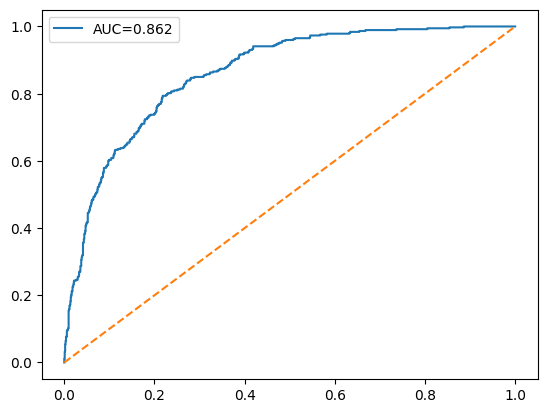

In [132]:
import matplotlib.pyplot as plt
plt.Figure(figsize=(8,6))
plt.plot(fpr,tpr,label=f'AUC={auc:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.legend()
plt.show()

The ROC Curve visualizes the trade-off between the True Positive Rate (Recall) and the False Positive Rate across different classification thresholds. The diagonal reference line represents random guessing. A model whose ROC curve lies significantly above the diagonal demonstrates strong discriminative ability. The closer the curve is to the top-left corner, the better the model is at distinguishing between positive and negative classes.

The Logistic Regression model achieved an AUC score of 0.862, indicating strong ability to distinguish between customers who churn and those who do not. The ROC curve remained significantly above the random guessing baseline, demonstrating that the model maintains a favorable trade-off between True Positive Rate and False Positive Rate across multiple classification thresholds. This suggests that the model is effective for churn prediction despite the class imbalance present in the dataset.

Another observation is that we have gotten lucky in this split we will perform CROSS VALIDATION

In [133]:
from sklearn.model_selection import cross_val_score

In [134]:
cv_scores = cross_val_score(LogisticModel,X_train_scaled,y_train,cv=5,scoring='roc_auc')

### Why ROC-AUC is Preferred for Churn Prediction

Customer churn datasets are often imbalanced, meaning the number of customers who do not churn is significantly higher than the number of customers who churn. In such cases, accuracy can be misleading because a model may achieve high accuracy simply by predicting the majority class most of the time.

ROC (Receiver Operating Characteristic) Curve evaluates a model's performance across all possible classification thresholds by plotting the True Positive Rate (Recall) against the False Positive Rate. This allows us to analyze how effectively the model distinguishes between churners and non-churners rather than relying on a single threshold value.

AUC (Area Under the Curve) summarizes the ROC Curve into a single metric. It measures the model's ability to rank positive instances higher than negative instances. An AUC value of 0.5 indicates random guessing, while a value closer to 1.0 indicates excellent discriminative ability.

ROC-AUC is preferred for churn prediction because:

1. It is less affected by class imbalance than accuracy.
2. It evaluates model performance across all classification thresholds.
3. It measures the model's ability to distinguish churners from non-churners.
4. It provides a more reliable assessment of classification performance when the positive class is relatively rare.
5. It helps compare different models objectively using a threshold-independent metric.

In this churn prediction project, ROC-AUC was used because identifying customers at risk of leaving is more important than simply maximizing overall prediction accuracy. A higher AUC score indicates that the model is effective at separating churning customers from non-churning customers and can therefore support better customer retention strategies.


In [135]:
for idx,score in enumerate(cv_scores):
    print(f'Fold{idx+1}:{score:.2f}')
mean=cv_scores.mean()
standard_d=cv_scores.std()
print(f'the mean of the CV_scores is:{mean:.2f}')
print(f'the standard deviation of all CV_scores is:{standard_d:.3f}')

Fold1:0.86
Fold2:0.84
Fold3:0.83
Fold4:0.83
Fold5:0.84
the mean of the CV_scores is:0.84
the standard deviation of all CV_scores is:0.012


### Cross Validation Results

To evaluate the stability and generalization capability of the Logistic Regression model, 5-Fold Cross Validation was performed using ROC-AUC as the evaluation metric. The model achieved cross-validation scores of 0.861, 0.842, 0.831, 0.828, and 0.841, resulting in a mean ROC-AUC score of 0.84 and a standard deviation of 0.012.

The low standard deviation indicates that the model performs consistently across different subsets of the dataset and is not heavily dependent on a particular train-test split. Additionally, the cross-validation mean is close to the ROC-AUC score obtained on the original test set (0.862), suggesting that the model generalizes well to unseen data and exhibits good predictive stability.


In [136]:
from sklearn.model_selection import GridSearchCV


In [137]:
parameter_grid = {'C':[0.01,0.1,1,10,100]}
Grid = GridSearchCV(estimator=LogisticModel,param_grid=parameter_grid,cv=5,scoring='roc_auc')

In [138]:
Grid.fit(X_train_scaled,y_train)
best_Paramter=Grid.best_params_
best_scor=Grid.best_score_

print(f'The best parameter is:{best_Paramter}')
print(f'The best Score is:{best_scor:.4f}')

The best parameter is:{'C': 100}
The best Score is:0.8411


### Hyperparameter Tuning using GridSearchCV

Hyperparameter tuning was performed on the Logistic Regression model using GridSearchCV with 5-Fold Cross Validation and ROC-AUC as the evaluation metric. The hyperparameter C, which controls the strength of regularization, was tested across multiple values: 0.01, 0.1, 1, 10, and 100.

The optimal value identified by GridSearchCV was C = 100, resulting in a mean cross-validation ROC-AUC score of 0.841. Compared to the baseline cross-validation score of 0.8408, the improvement was negligible, indicating that the default Logistic Regression model was already performing near its optimal configuration. This demonstrates that hyperparameter tuning does not always lead to significant performance gains and that model performance is often influenced more by data quality and feature engineering than by parameter adjustments alone.


NOW LETS DO THE SAME EVALUATION STEPS FOR THE FOLLOWING RANDOM FOREST MODEL AND COMPARE THE METRICS

In [139]:
y_prob_rf = RandomForest.predict_proba(X_test_scaled)[:,1]

c:\Users\Abhinav\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [140]:
pd.DataFrame(y_prob_rf)

,0
0,0.85
1,0.28
2,0.15
3,0.79
4,0.19
...,...
1404,0.36
1405,0.47
1406,0.06
1407,0.39


In [141]:
from sklearn.metrics import roc_auc_score
rf_score = roc_auc_score(y_test,y_prob_rf)

In [142]:
print(rf_score)


0.802493608123635


[]

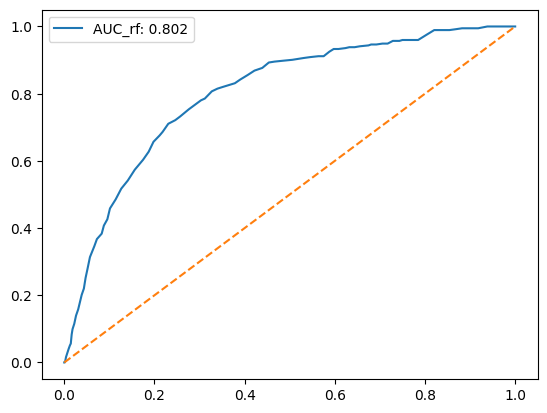

In [143]:
from sklearn.metrics import roc_curve
fpr_rf,tpr_rf,threshold_rf = roc_curve(y_test,y_prob_rf)
plt.Figure(figsize=(8,6))
plt.plot(fpr_rf,tpr_rf,label=f'AUC_rf: {rf_score:.3f}')
plt.plot([0,1],[0,1],linestyle='--')
plt.legend()
plt.plot()

In [144]:
from sklearn.model_selection import cross_val_score
rf_score_val = cross_val_score(RandomForest,X_train_scaled,y_train,cv=5,scoring='roc_auc')

In [145]:
print(rf_score_val)
rf_score_mean = rf_score_val.mean()
rf_score_std = rf_score_val.std()

print(f'The mean for the random forest score is:{rf_score_mean:.3f}')
print(f'the standard deviation for the random forest is:{rf_score_std:.3f}')

[0.84621645 0.82606272 0.80735099 0.81970979 0.82393549]
The mean for the random forest score is:0.825
the standard deviation for the random forest is:0.013


### Model Comparison and Selection

Two machine learning models were evaluated for customer churn prediction: Logistic Regression and Random Forest Classifier. Model performance was assessed using ROC-AUC and 5-Fold Cross Validation to ensure a fair and reliable comparison.

Logistic Regression achieved a cross-validation ROC-AUC score of 0.841 with a standard deviation of 0.012, while Random Forest achieved a cross-validation ROC-AUC score of 0.825 with a standard deviation of 0.013. Both models demonstrated stable performance across folds; however, Logistic Regression consistently achieved better discriminative performance.

Based on the evaluation results, Logistic Regression was selected as the final model. In addition to achieving the highest ROC-AUC score, it offers greater interpretability, making it easier to understand the factors contributing to customer churn. This is particularly valuable in business settings where actionable insights are as important as predictive performance.


# feature Importance

In [146]:
importances = RandomForest.feature_importances_
feature_importance_rf = pd.DataFrame({'features':X.columns,'Importance':importances}) 
feature_importance_rf = feature_importance_rf.sort_values('Importance',ascending=False)

In [147]:
feature_importance_rf.head(10)

,features,Importance
3,TotalCharges,0.189701
1,tenure,0.175710
2,MonthlyCharges,0.172418
10,InternetService_Fiber optic,0.036053
28,PaymentMethod_Electronic check,0.035302
25,Contract_Two year,0.030435
13,OnlineSecurity_Yes,0.029238
4,gender_Male,0.027423
26,PaperlessBilling_Yes,0.025295
5,Partner_Yes,0.024209


### Feature Importance Analysis

Feature importance analysis was performed using the Random Forest Classifier to identify the variables that contributed most to churn prediction. The three most influential features were TotalCharges (0.190), tenure (0.176), and MonthlyCharges (0.172), indicating that customer spending behavior and length of service are the strongest predictors of churn.

Additional influential features included InternetService_Fiber optic, PaymentMethod_Electronic check, and Contract_Two year, suggesting that service characteristics and payment preferences also play a role in customer retention. In contrast, demographic features such as gender exhibited relatively low importance, indicating that customer behavior and financial attributes are more informative than demographic characteristics.

These findings suggest that retention strategies should primarily focus on customer value, tenure management, pricing structures, and contract offerings rather than demographic segmentation.


In [148]:
import joblib

joblib.dump(LogisticModel, '../models/logistic_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')

['../models/scaler.pkl']

In [149]:
print(LogisticModel)

LogisticRegression(max_iter=1000)


In [150]:
import joblib

joblib.dump(
    X.columns.tolist(),
    '../models/feature_columns.pkl'
)

['../models/feature_columns.pkl']

In [151]:
import joblib

features = joblib.load(
    '../models/feature_columns.pkl'
)

print(len(features))

30
